# Random Variables & Distributions

概率统计开篇：把"随机试验"翻译成数学语言。本课建立随机变量、PMF/PDF/CDF 三件套，理解离散与连续分布的完整描述方式。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 随机变量：把随机性变成数


随机变量 $X$ 是"随机试验结果"到实数的映射。分两类：

- **离散**：取值可数（抛硬币 0/1、掷骰子 1-6、二项计数）
- **连续**：取值是区间（身高、温度、噪声振幅）

分布 = 随机变量取各个值的概率规律。描述它的三件套：PMF / PDF / CDF。


## 2. 离散分布：概率质量函数 PMF


$p(x) = P(X = x)$，满足 $p(x) \ge 0$ 且 $\sum_x p(x) = 1$。

三个最常用的离散分布：

| 分布 | PMF | 参数 | 直觉 |
|------|-----|------|------|
| 伯努利 | $p^x(1-p)^{1-x}$ | $p$ | 一次成功/失败 |
| 二项 | $\binom{n}{k}p^k(1-p)^{n-k}$ | $n, p$ | $n$ 次独立试验的成功次数 |
| 泊松 | $e^{-\lambda}\lambda^k/k!$ | $\lambda$ | 稀有事件计数（λ = 平均发生数） |


二项 PMF 求和 = 1.0 （应为 1）
泊松 PMF 求和 = 0.9999999999999999 （应为 1）


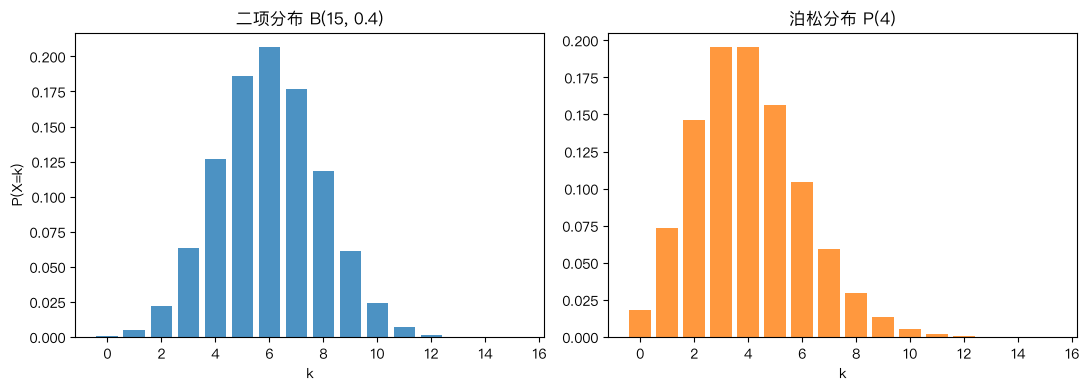

In [2]:
def binom_pmf(k, n, p):
    return math.comb(n, k) * p**k * (1-p)**(n-k)

def poisson_pmf(k, lam):
    return math.exp(-lam) * lam**k / math.factorial(k)

ks = np.arange(0, 16)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 二项 B(15, 0.4)
axes[0].bar(ks, [binom_pmf(k, 15, 0.4) for k in ks], color='tab:blue', alpha=0.8)
axes[0].set_title('二项分布 B(15, 0.4)'); axes[0].set_xlabel('k'); axes[0].set_ylabel('P(X=k)')

# 泊松 P(4)
axes[1].bar(ks, [poisson_pmf(k, 4) for k in ks], color='tab:orange', alpha=0.8)
axes[1].set_title('泊松分布 P(4)'); axes[1].set_xlabel('k')

plt.tight_layout()
print("二项 PMF 求和 =", sum(binom_pmf(k, 15, 0.4) for k in range(16)), "（应为 1）")
print("泊松 PMF 求和 =", sum(poisson_pmf(k, 4) for k in range(40)), "（应为 1）")


## 3. 连续分布：概率密度函数 PDF 与累积分布 CDF


连续情形 $P(X = x) = 0$（单点概率为零），改用**密度** $p(x)$ 描述：

$$P(a \le X \le b) = \int_a^b p(x)\,dx, \qquad \int_{-\infty}^{\infty} p(x)\,dx = 1$$

**累积分布函数** $F(x) = P(X \le x) = \int_{-\infty}^x p(t)\,dt$，单调不减，且 $F'(x) = p(x)$。

| 分布 | 密度 $p(x)$ | 支撑 |
|------|------------|------|
| 均匀 $U(a,b)$ | $1/(b-a)$ | $[a,b]$ |
| 指数 $\mathrm{Exp}(\lambda)$ | $\lambda e^{-\lambda x}$ | $x \ge 0$ |
| 正态 $N(\mu,\sigma^2)$ | $\tfrac{1}{\sqrt{2\pi}\sigma}e^{-(x-\mu)^2/2\sigma^2}$ | $\mathbb{R}$ |


P(0.5≤X≤2) 数值积分 = 0.468424
P(0.5≤X≤2) 解析 F(b)-F(a) = 0.468424
密度全域积分 = 1.000000（应为 1）


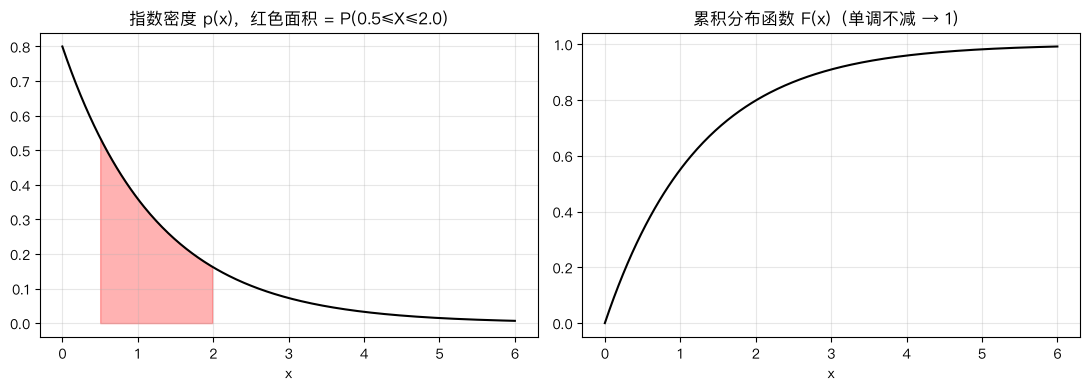

In [3]:
def mid_integral(g, a, b, n=50000):
    xs = np.linspace(a, b, n+1)
    mids = (xs[:-1] + xs[1:]) / 2
    return np.sum(g(mids)) * (b - a) / n

# 指数分布 Exp(0.8)
lam = 0.8
p = lambda x: lam * np.exp(-lam * x)
F = lambda x: 1 - np.exp(-lam * x)

# 数值积分验证 P(0.5 ≤ X ≤ 2) = ∫₀.₅² λe^{-λx}dx = F(2) - F(0.5)
a, b = 0.5, 2.0
numeric = mid_integral(p, a, b)
analytic = F(b) - F(a)
print(f"P(0.5≤X≤2) 数值积分 = {numeric:.6f}")
print(f"P(0.5≤X≤2) 解析 F(b)-F(a) = {analytic:.6f}")
print(f"密度全域积分 = {mid_integral(p, 0, 30):.6f}（应为 1）")

xs = np.linspace(0, 6, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(xs, p(xs), 'k-'); axes[0].fill_between(xs, 0, p(xs), where=(xs>=a)&(xs<=b), alpha=0.3, color='red')
axes[0].set_title(f'指数密度 p(x)，红色面积 = P({a}≤X≤{b})')
axes[1].plot(xs, F(xs), 'k-'); axes[1].set_title('累积分布函数 F(x)（单调不减 → 1）')
for ax in axes: ax.set_xlabel('x'); ax.grid(alpha=0.3)
plt.tight_layout()


## 4. CDF 与 PDF 互逆：数值验证


$F'(x) = p(x)$——对 CDF 数值求导应得到 PDF。这直接呼应微积分基本定理（calculus 07）。


最大误差: 0.0002058991801312778


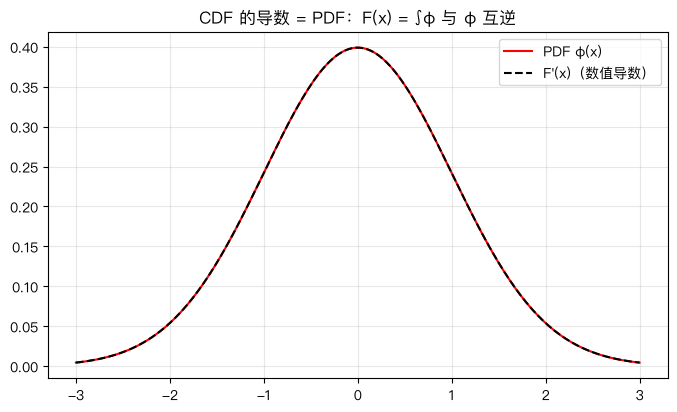

In [4]:
# 标准正态：F 的数值导数 ≈ φ
phi = lambda x: np.exp(-x**2/2) / np.sqrt(2*np.pi)
def normal_cdf(x):
    return 0.5 * (1 + math.erf(x / np.sqrt(2)))

xs = np.linspace(-3, 3, 200)
F_vals = np.array([normal_cdf(x) for x in xs])
F_deriv = np.gradient(F_vals, xs)          # 数值导数

plt.figure(figsize=(8, 4.5))
plt.plot(xs, phi(xs), 'r-', label='PDF φ(x)')
plt.plot(xs, F_deriv, 'k--', label="F'(x)（数值导数）")
plt.legend(); plt.grid(alpha=0.3)
plt.title('CDF 的导数 = PDF：F(x) = ∫φ 与 φ 互逆')
print("最大误差:", np.abs(phi(xs) - F_deriv).max())


## 5. 分布的"形状特征"预览


分布不只是图形，还由**数字特征**刻画：期望（中心）、方差（分散程度）。这是下一课的主题。先把直觉建立起来：

- 二项 $B(n,p)$：均值 $np$，峰在 $np$ 附近
- 泊松 $P(\lambda)$：均值 $\lambda$，偏右尾
- 指数：无记忆性 $P(X>s+t\,|\,X>s) = P(X>t)$（为什么？因为 $P(X>u)=e^{-\lambda u}$）
- 正态：对称钟形，68-95-99.7 法则（calculus 07 已验证）


## 6. 与深度学习的关系

深度学习的每个环节都在"选分布"：

- **噪声假设**：回归误差假设高斯 → 用 MSE；分类输出假设伯努利 → 用 BCE
- **参数与初始化**：权重初始化就是在选先验分布（05 课）
- **输出层**：分类任务的输出就是估计 $P(y|x)$，softmax 输出一个分布
- **Dropout / 数据增强**：都是在向训练过程注入随机性（正则化）

概率统计模块的每一课都会标注这个"分布选择"的视角。


## 课后练习


1. **手推**：二项分布 $B(n,p)$ 的 PMF 求和为 1（提示：二项式定理 $(p+q)^n$）。
2. **泊松近似**：$n=100, p=0.02$ 的二项分布与 $\lambda=2$ 的泊松分布画在一起比较，看是否接近。
3. **指数无记忆**：数值验证 $P(X>3|X>1) = P(X>2)$（$X \sim \mathrm{Exp}(0.8)$）。
4. **CDF 性质**：对任意 $a<b$，证明 $P(a \le X \le b) = F(b) - F(a)$。
5. **绘图**：画出 $N(0,1)$、$N(2, 0.5^2)$ 两条密度曲线，观察均值与方差如何改变图形。
